|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Build a GPT<h1>|
|<h2>Lecture:</h2>|<h1><b>The Transformer block (code)<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

import torch
import torch.nn as nn
import torch.nn.functional as F

# vector plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Demo of linear separation after dimensionality expansion

C:\Users\Alex Huang2\AppData\Local\Temp\ipykernel_47216\2396038546.py:36: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


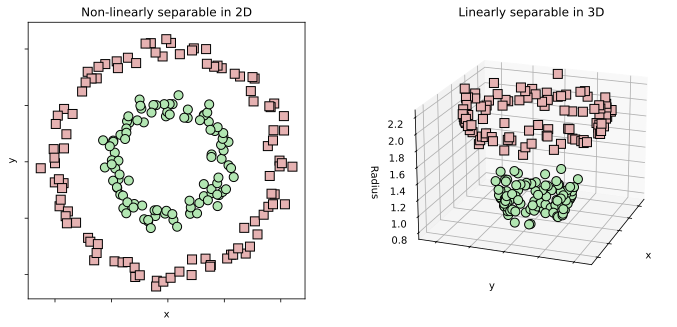

In [2]:
# angles
n = 100
theta = np.linspace(0,2*np.pi-1/n,n)

# coordinates in 2D
x_inner = 1*np.cos(theta) + np.random.randn(n)/10
y_inner = 1*np.sin(theta) + np.random.randn(n)/10
x_outer = 2*np.cos(theta) + np.random.randn(n)/10
y_outer = 2*np.sin(theta) + np.random.randn(n)/10

# dimensionality-expansion via nonlinear transform
z_inner = np.sqrt(x_inner**2 + y_inner**2)
z_outer = np.sqrt(x_outer**2 + y_outer**2)



### 2D scatter plot
fig = plt.figure(figsize=(12,5))
ax0 = fig.add_subplot(121)

ax0.plot(x_inner,y_inner,'ko',markerfacecolor=[.7,.9,.7],markersize=9)
ax0.plot(x_outer,y_outer,'ks',markerfacecolor=[.9,.7,.7],markersize=9)
ax0.axis('square')
ax0.set(title='Non-linearly separable in 2D',xlabel='x',ylabel='y',
        xticklabels=[],yticklabels=[])

### 3D scatter plot
ax1 = fig.add_subplot(122, projection='3d')
ax1.plot(x_inner,y_inner,z_inner,'ko',markerfacecolor=[.7,.9,.7],markersize=9)
ax1.plot(x_outer,y_outer,z_outer,'ks',markerfacecolor=[.9,.7,.7],markersize=9)
ax1.set(title='Linearly separable in 3D',xlabel='x',ylabel='y',zlabel='Radius',
        xticklabels=[],yticklabels=[])
ax1.view_init(20,20)


plt.tight_layout()
plt.show()

# And now to the main part of the code :)

# Model hyperparameters

In [3]:
# data hyperparameters
seq_len = 8

# model hyperparameters
embed_dim = 128

# training hyperparameters
batch_size = 5

# One attention head

In [ ]:
# Note: This "One attention head" section is for viewing dimentsions of each layer or sublayer. 
#       You don't Need this section when training a model.
#       You can skip to next section "Transformer block".


# create one attention head
class OneAttentionHead(nn.Module):
  def __init__(self,embed_dim):
    super().__init__()

    # create the k/q/v matrices
    self.key   = nn.Linear(embed_dim,embed_dim,bias=False)
    self.query = nn.Linear(embed_dim,embed_dim,bias=False)
    self.value = nn.Linear(embed_dim,embed_dim,bias=False)
    self.W0    = nn.Linear(embed_dim,embed_dim,bias=False)

  def forward(self,x):

    # run the token embeddings vectors through attention
    k = self.key(x)
    q = self.query(x)
    v = self.value(x)
    y = F.scaled_dot_product_attention(q,k,v,is_causal=True)  # Make sure to set is_causal=True to make 
                                                              # sure that the time causal mask is included.
    y = self.W0(y) # linear weightings post-attention

    return y

In [5]:
# explore the attention head
onehead = OneAttentionHead(embed_dim)

print(onehead)

# run some fake data through
tokenEmbeds = torch.randn(batch_size, seq_len, embed_dim)
out = onehead(tokenEmbeds)
print(f'\nOutput ({out.shape}): \n{out}')

OneAttentionHead(
  (key): Linear(in_features=128, out_features=128, bias=False)
  (query): Linear(in_features=128, out_features=128, bias=False)
  (value): Linear(in_features=128, out_features=128, bias=False)
  (W0): Linear(in_features=128, out_features=128, bias=False)
)

Output (torch.Size([5, 8, 128])): 
tensor([[[-0.2564,  0.2088, -0.1999,  ..., -0.0140,  0.5356, -0.2173],
         [ 0.0652,  0.1321,  0.1116,  ...,  0.0911,  0.2604, -0.2111],
         [-0.0113,  0.1042, -0.0143,  ...,  0.1118,  0.1291, -0.2364],
         ...,
         [-0.0579,  0.1975, -0.1506,  ..., -0.0329,  0.1223, -0.0588],
         [ 0.0549,  0.1162, -0.1667,  ...,  0.0363,  0.1719, -0.0722],
         [ 0.1176,  0.1737, -0.2088,  ...,  0.0184,  0.1462,  0.0362]],

        [[-0.1010, -0.0244, -0.4998,  ..., -0.1247, -0.1001, -0.1608],
         [ 0.1634,  0.1555, -0.3649,  ...,  0.0578, -0.0600, -0.0755],
         [ 0.2508, -0.0053, -0.4314,  ..., -0.0239, -0.1659, -0.0821],
         ...,
         [ 0.1308,  

# Transformer block

In [6]:
#
class TransformerBlock(nn.Module):
  def __init__(self,embed_dim):
    super().__init__()

    # attention sublayer
    self.layerNormAttn = nn.LayerNorm(embed_dim)
    self.attn = OneAttentionHead(embed_dim)

    # feedforward (MLP) sublayer
    self.layerNormMLP  = nn.LayerNorm(embed_dim)
    self.W1   = nn.Linear(embed_dim,4*embed_dim) # 4x expansion
    self.gelu = nn.GELU()                        # nonlinearity
    self.W2   = nn.Linear(4*embed_dim,embed_dim) # 4x contraction


  def forward(self,x):

    ## --- attention sublayer --- ##
    # save a copy of pre-attention data
    residual = x

    # layernorm -> attention
    h        = self.layerNormAttn(x)
    attn_out = self.attn(h)

    # combine pre-attention copy + attention adjustments
    x        = residual + attn_out

    # note: could do this in one line:
    #x = x + self.attn(self.layerNormAttn(x))
    ## -------------------------- ##



    ## ------ MLP sublayer ------ ##
    # copy of pre-MLP data
    residual2 = x

    # layernorm before MLP
    h2        = self.layerNormMLP(x)

    # expansion-nonlinearity-contraction
    mlp_out   = self.W2(self.gelu(self.W1(h2)))

    # combine pre-MLP copy + MLP-adjustment
    y         = residual2 + mlp_out
    ## -------------------------- ##


    return y

In [7]:
# create and explore an instance
transblock = TransformerBlock(embed_dim)
print(transblock)

TransformerBlock(
  (layerNormAttn): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (attn): OneAttentionHead(
    (key): Linear(in_features=128, out_features=128, bias=False)
    (query): Linear(in_features=128, out_features=128, bias=False)
    (value): Linear(in_features=128, out_features=128, bias=False)
    (W0): Linear(in_features=128, out_features=128, bias=False)
  )
  (layerNormMLP): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (W1): Linear(in_features=128, out_features=512, bias=True)
  (gelu): GELU(approximate='none')
  (W2): Linear(in_features=512, out_features=128, bias=True)
)


In [8]:
# again, pushing data through
out = transblock(tokenEmbeds)
print(f'\nOutput ({out.shape}): \n{out}')


Output (torch.Size([5, 8, 128])): 
tensor([[[-4.6210e-01, -2.1629e+00, -1.2658e+00,  ...,  4.3369e-01,
           8.2985e-01,  1.5590e+00],
         [-1.9489e+00, -2.7844e-02, -7.8053e-02,  ..., -1.2790e-01,
          -2.1489e+00, -1.2672e+00],
         [ 8.3603e-01,  9.8440e-01,  1.6673e+00,  ..., -1.0382e+00,
          -3.8744e-01, -1.5315e-01],
         ...,
         [ 3.1653e-02,  8.2607e-01,  2.1026e-01,  ..., -2.0874e+00,
           2.5522e-01,  1.1435e-01],
         [ 6.3377e-01,  2.4059e+00,  1.1803e+00,  ...,  5.5835e-02,
           1.0507e+00,  6.3909e-01],
         [ 3.0057e-01,  2.5653e-01,  1.0371e+00,  ...,  8.4147e-01,
          -1.6554e+00,  1.5227e+00]],

        [[-2.2962e+00,  8.7726e-01, -4.2687e-01,  ..., -1.4497e+00,
           7.4421e-01, -1.2631e+00],
         [ 1.9012e+00, -3.5980e-01, -4.7323e-01,  ..., -2.1468e+00,
           1.3563e-01,  2.7296e-01],
         [ 1.0264e+00,  1.1045e+00, -6.5705e-01,  ...,  9.2743e-02,
          -1.5276e+00,  2.5072e-01],
   